#California Housing Prices Project

Dataset from Kaggle

In [52]:
#import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Data Cleaning and Pre-processing

In [54]:
#load dataset
#when uploading to colab
df = pd.read_csv('housing.csv')
display(df.head())

#else if mounting google drive
#from google.colab import drive
#drive.mount('/content/drive') UPDATE PATH

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [55]:
df.shape

(20640, 10)

The dataframe contains 9 features to predict 1 target variable and 20640 observations.

In [56]:
df.isna().sum() #check missing values

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


The 207 rows with missing values for total_bedrooms represents roughly 1% of total data points. We will drop these rows from the data frame.

In [57]:
df = df.dropna()
df.shape

(20433, 10)

In [58]:
display(df.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


median_income is measured in tens of thousands of USD and median_house_value is measured in USD. To make these numerical values consistent, median income is multiplied by 10,000 to ensure it is in USD.

In [59]:
df["median_income"] = df["median_income"]*10000

Total rooms and total bedrooms columns are dependant on the number of households in each block. By replacing these two columns with the average number of rooms and average number of bedrooms per household, we make this value comparable to other observations.

In [60]:
df["avg_bedrooms_per_household"] = df["total_bedrooms"] / df["households"]
df["avg_rooms_per_household"] = df["total_rooms"] / df["households"]
print("avg_bedrooms_per_household")
display(df["avg_bedrooms_per_household"].describe())
print("avg_rooms_per_household")
display(df["avg_rooms_per_household"].describe())

avg_bedrooms_per_household


,avg_bedrooms_per_household
count,20433.000000
mean,1.097062
std,0.476104
min,0.333333
25%,1.006029
50%,1.048889
75%,1.099631
max,34.066667


avg_rooms_per_household


,avg_rooms_per_household
count,20433.000000
mean,5.431344
std,2.482946
min,0.846154
25%,4.441441
50%,5.230769
75%,6.052381
max,141.909091


Mean of average number of bedrooms per household is 1.1 and mean of average number of rooms per household is 5.4. Minimum average numbers are 0.33 bedrooms per household and 0.85 total rooms per household. This suggests there are blocks where there are more households than bedrooms and rooms.

This could be a classification technicality, where spaces in a building are not classified as "bedrooms" or "rooms" resulting in instances where there are more households in a block than there are total rooms or bedrooms.

In [61]:
a = df['households']>df['total_rooms']
display(a.describe())

,0
count,20433
unique,2
top,False
freq,20431


20433 -20431 = 2 instances where households > total_rooms

In [62]:
b = df['households']>df['total_bedrooms']
display(b.describe())

,0
count,20433
unique,2
top,False
freq,16081


20433 - 16081 = 4352 instances where households > total_bedrooms

Dividing the population by households shows the average household size. Like with average rooms there is a massive spread of household populations with averages ranging from 0.69 to 1243.33

In [63]:
#create avg_house_pop = population / households
df["avg_house_population"] = df["population"] / df["households"]
print("avg_house_population")
display(df["avg_house_population"].describe())

avg_house_population


,avg_house_population
count,20433.000000
mean,3.071533
std,10.438269
min,0.692308
25%,2.429032
50%,2.817582
75%,3.281513
max,1243.333333


avg_house_population < 1 if population < households. This implies the existance of empty rooms or buildings.

Representing categorical values with numerical dummy values. They cannot be manually assigned numbers as we cannot establish a linear relationship between increasing value of a numerical variable and the difference between the present categories.

In [64]:
display(df["ocean_proximity"].unique())

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [65]:
df = pd.get_dummies(df)

In [66]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,avg_bedrooms_per_household,avg_rooms_per_household,avg_house_population,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,83252.0,452600.0,1.023810,6.984127,2.555556,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,83014.0,358500.0,0.971880,6.238137,2.109842,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,72574.0,352100.0,1.073446,8.288136,2.802260,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,56431.0,341300.0,1.073059,5.817352,2.547945,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,38462.0,342200.0,1.081081,6.281853,2.181467,False,False,False,True,False


From above descriptive statistics, we know that there some outliers in certain features. We will leave these outliers in for now and remove them from a duplicated dataframe later and see how these two different dataframes perform in the same models to see the impact of outliers on model performance.

#Data Visualisation

Text(0.5, 1.0, 'Correlation Matrix of Features')

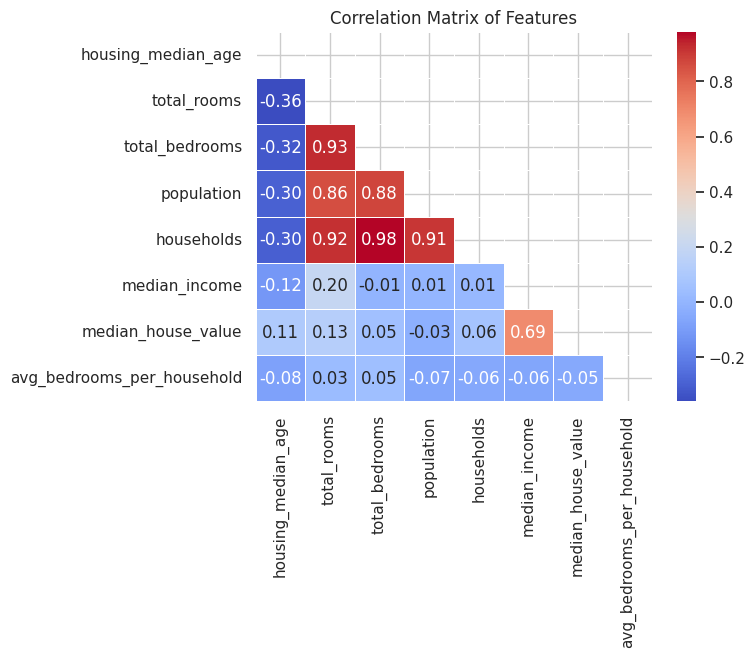

In [67]:
df2 = df.iloc[:,2:10]
# Set plot style
sns.set_theme(style="whitegrid")

# Correlation Matrix Heatmap
#plt.figure(figsize=(10, 8))
corr_matrix = df2.corr()

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask)
plt.title("Correlation Matrix of Features")

Median income seems to be most correlated with median house value.

Text(0, 0.5, 'Frequency')

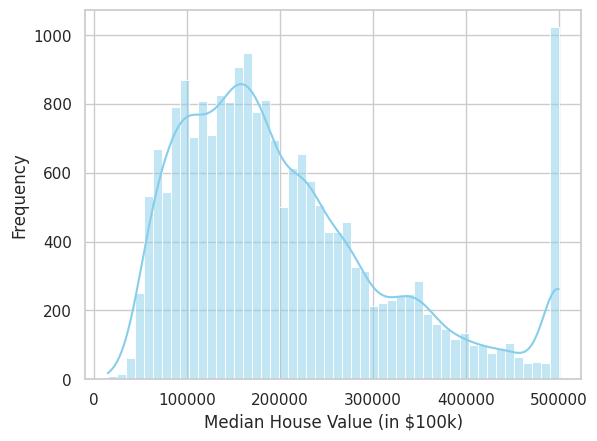

In [68]:
#Histogram of Target Variable (MedHouseVal)
#plt.figure(figsize=(8, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='skyblue')
#plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value (in $100k)")
plt.ylabel("Frequency")

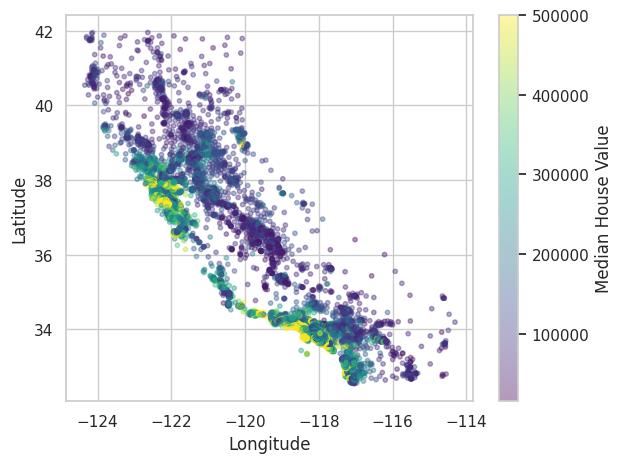

In [69]:
#Geographic Scatter Plot (Latitude vs Longitude)
#plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Median House Value')
#plt.title("Geographic Distribution of Housing Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

Coastal properties generally have larger median house value compared to inland properties. Density does not seem to have a distinct impact on house value.

#Data Modelling

In [72]:
#create functions for fitting and training models for simplicity in future code

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

def fit_train(X, y, models):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Scale features
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  # Evaluate Models
  print(f"{'Model':<20} | {'RMSE':<10} | {'R² Score':<10}")
  print("-" * 45)

  for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{name:<20} | {rmse:.4f}     | {r2:.4f}")

In [70]:
#Prepare data
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

fit_train(X,y,models)

Model                | RMSE       | R² Score  
---------------------------------------------
Linear Regression    | 69874.4040     | 0.6430
Decision Tree        | 70048.6394     | 0.6412
Random Forest        | 51269.0804     | 0.8078


We want to drop highly correlated features to see the impact on model performance.

In [71]:
X_c = df.drop(['total_rooms', 'avg_bedrooms_per_household', 'population', 'median_house_value'], axis=1)
fit_train(X_c,y,models)

Model                | RMSE       | R² Score  
---------------------------------------------
Linear Regression    | 72229.2764     | 0.6185
Decision Tree        | 70580.3631     | 0.6357
Random Forest        | 50919.8076     | 0.8104


We see minor improvements in RMSE and R2 score.

Now we try dropping outliers in the data and retrain the models with and without highly correlated features.

Try